# City Air Quality Explorer — Delhi, 2023

**Goal:** turn a year of raw, messy hourly air-quality sensor readings into a
clean dataset and a set of charts that show *when* and *where* Delhi's air is
most dangerous to breathe — the kind of view a health department would
actually act on.

**Station:** Anand Vihar, Delhi &nbsp;|&nbsp; **Period:** Jan 1 – Dec 31, 2023 (hourly)
&nbsp;|&nbsp; **Pollutants:** PM2.5, PM10, NO2, SO2, CO, O3

**Pipeline:** Load & audit → Clean → Engineer time features → Aggregate →
Visualise → Write findings → Save cleaned CSV + charts


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

plt.rcParams["figure.dpi"] = 110

RAW_PATH = "delhi_air_quality_2023_raw.csv"
CLEAN_PATH = "delhi_air_quality_2023_clean.csv"
CHARTS_DIR = "charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

POLLUTANTS = ["pm25", "pm10", "no2", "so2", "co", "o3"]

# WHO 2021 Air Quality Guidelines (24-hour mean, ug/m3)
WHO_24H = {"pm25": 15, "pm10": 45, "no2": 25, "so2": 40}
# India National Ambient Air Quality Standards (24-hour mean, ug/m3)
NAAQS_24H = {"pm25": 60, "pm10": 100, "no2": 80, "so2": 80}

# Domain sanity caps -- a reading above these is almost certainly a sensor
# fault, not a real value, even for Delhi's worst smog episodes
SANITY_MAX = {"pm25": 1500, "pm10": 2500, "no2": 500, "so2": 300, "co": 30, "o3": 300}


## Step 1 — Load the raw CSV and run a first audit

Before touching anything, check: shape, dtypes, null counts, duplicate
timestamps, the unit labels actually present, and the min/max range of each
pollutant. This is where most real-world problems first reveal themselves.


In [2]:
raw = pd.read_csv(RAW_PATH)

print("Shape:", raw.shape)
print("\nDtypes:")
print(raw.dtypes)


Shape: (8822, 14)

Dtypes:
timestamp        str
city             str
station          str
pm25         float64
pm25_unit        str
pm10         float64
pm10_unit        str
no2          float64
so2          float64
co           float64
o3           float64
temp_c       float64
rh_pct       float64
wind_kmh     float64
dtype: object


In [3]:
print("Null counts per column:")
print(raw.isna().sum())


Null counts per column:
timestamp      0
city           0
station        0
pm25         434
pm25_unit      0
pm10         449
pm10_unit      0
no2          462
so2          423
co           432
o3           294
temp_c       210
rh_pct         0
wind_kmh     276
dtype: int64


In [4]:
print("Duplicate timestamps:", raw["timestamp"].duplicated().sum())
print("PM2.5 unit values found:", list(raw["pm25_unit"].unique()))
print("\nValue ranges (numeric pollutants):")
print(raw[POLLUTANTS].describe().T[["min", "max", "mean"]].round(1))


Duplicate timestamps: 80
PM2.5 unit values found: ['ug/m3', 'mg/m3']

Value ranges (numeric pollutants):
       min      max   mean
pm25 -19.1  15816.2  123.7
pm10   0.0   2206.8  203.3
no2   10.0   2087.1   36.9
so2    3.1     36.9   11.7
co     0.3      6.1    1.3
o3     2.9    133.5   22.5


**What the audit already tells us:**
- Thousands of nulls scattered across pollutant columns, plus the value ranges
  look implausible (PM2.5 min is negative, max is in the tens of thousands —
  physically impossible).
- There are duplicate timestamps — the sensor (or export process) logged some
  hours twice.
- The PM2.5 unit column has *two* distinct values (`ug/m3` and `mg/m3`) — a
  batch of readings was logged 1000x too small.

Each of these gets fixed explicitly in Step 2, rather than just dropped.


## Step 2 — Clean

1. Parse timestamps to real datetimes.
2. Standardise units — collapse the `mg/m3`-tagged PM rows back to `ug/m3`.
3. Null out physically impossible values (negative readings, decimal-shift
   spikes above a domain-sanity cap) so they get treated as missing rather
   than silently skewing every average downstream.
4. De-duplicate timestamps (drop exact repeats; average conflicting repeats).
5. Reindex to the **complete** hourly grid for the year, so hours that never
   made it into the export show up as explicit gaps instead of being silently
   absent.
6. Fill remaining gaps with time-based interpolation.


In [5]:
df = raw.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Standardise units: anything tagged mg/m3 gets multiplied back to ug/m3
for col, unit_col in [("pm25", "pm25_unit"), ("pm10", "pm10_unit")]:
    is_mg = df[unit_col] == "mg/m3"
    print(f"{col}: fixing {is_mg.sum()} rows logged in mg/m3")
    df.loc[is_mg, col] = df.loc[is_mg, col] * 1000
    df[unit_col] = "ug/m3"


pm25: fixing 241 rows logged in mg/m3
pm10: fixing 241 rows logged in mg/m3


In [6]:
# Null out physically impossible values
for col in POLLUTANTS:
    n_neg = (df[col] < 0).sum()
    n_spike = (df[col] > SANITY_MAX[col]).sum()
    if n_neg or n_spike:
        print(f"{col}: {n_neg} negative, {n_spike} above sanity cap -> set to NaN")
    df.loc[df[col] < 0, col] = np.nan
    df.loc[df[col] > SANITY_MAX[col], col] = np.nan


pm25: 7 negative, 3 above sanity cap -> set to NaN
no2: 0 negative, 4 above sanity cap -> set to NaN


In [7]:
# De-duplicate timestamps
before = len(df)
df = df.drop_duplicates()                      # exact double-logged rows
df = df.groupby("timestamp", as_index=False).agg(
    {**{c: "mean" for c in POLLUTANTS + ["temp_c", "rh_pct", "wind_kmh"]},
     "city": "first", "station": "first",
     "pm25_unit": "first", "pm10_unit": "first"}
)
print(f"Rows removed by de-duplication: {before - len(df)}")
print(f"Duplicate timestamps remaining: {df['timestamp'].duplicated().sum()}")


Rows removed by de-duplication: 80
Duplicate timestamps remaining: 0


In [8]:
# Reindex to a complete hourly grid so missing HOURS are explicit, not absent
df = df.set_index("timestamp").sort_index()
full_range = pd.date_range("2023-01-01 00:00", "2023-12-31 23:00", freq="h")
missing_hours = full_range.difference(df.index)
print(f"Hours that were missing from the export entirely: {len(missing_hours)}")

df = df.reindex(full_range)
df["city"] = df["city"].ffill().bfill()
df["station"] = df["station"].ffill().bfill()
df["pm25_unit"] = "ug/m3"
df["pm10_unit"] = "ug/m3"


Hours that were missing from the export entirely: 18


In [9]:
# Fill remaining gaps with time-based interpolation
null_before = df[POLLUTANTS].isna().sum().sum()
for col in POLLUTANTS + ["temp_c", "rh_pct", "wind_kmh"]:
    df[col] = df[col].interpolate(method="time", limit_direction="both")
null_after = df[POLLUTANTS].isna().sum().sum()

df = df.reset_index().rename(columns={"index": "timestamp"})

print(f"Nulls filled by interpolation: {null_before - null_after}")
print(f"Nulls remaining: {null_after}")
print(f"\nRows: {len(df)}  |  PM2.5 range now: {df['pm25'].min():.1f} - {df['pm25'].max():.1f}")


Nulls filled by interpolation: 2601
Nulls remaining: 0

Rows: 8760  |  PM2.5 range now: 12.2 - 1435.9


Two of those interpolated stretches are worth flagging explicitly rather
than treating as equally trustworthy as a normal hour: the **Mar 10–11**
sensor-maintenance outage and the **Aug 5–7** waterlogging outage, each 2–3
days long. Interpolation assumes a gradual change across the gap, which is a
reasonable guess for a couple of hours but a weaker one across multiple days —
worth a caveat in the final write-up rather than hiding it.


## Step 3 — Engineer time features, then save the cleaned dataset


In [10]:
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.day_name()
df["weekday_num"] = df["timestamp"].dt.weekday
df["month"] = df["timestamp"].dt.month
df["month_name"] = df["timestamp"].dt.month_name()
df["date"] = df["timestamp"].dt.date
df["is_weekend"] = df["weekday_num"] >= 5

df_out = df.drop(columns=["weekday_num"])
df_out.to_csv(CLEAN_PATH, index=False)
print(f"Saved cleaned dataset -> {CLEAN_PATH}  ({len(df_out):,} rows, {df_out.isna().sum().sum()} nulls)")
print()
print(df_out.head().to_string())


Saved cleaned dataset -> delhi_air_quality_2023_clean.csv  (8,760 rows, 0 nulls)

            timestamp   pm25   pm10   no2    so2    co    o3  temp_c  rh_pct  wind_kmh   city      station pm25_unit pm10_unit  hour weekday  month month_name        date  is_weekend
0 2023-01-01 00:00:00  158.5  252.0  31.4  13.40  0.76   6.6     7.3    82.0       4.5  Delhi  Anand Vihar     ug/m3     ug/m3     0  Sunday      1    January  2023-01-01        True
1 2023-01-01 01:00:00  145.2  242.8  33.1  12.90  1.10   6.1     5.5    83.0       6.2  Delhi  Anand Vihar     ug/m3     ug/m3     1  Sunday      1    January  2023-01-01        True
2 2023-01-01 02:00:00  205.8  334.6  38.8  12.20  1.33   6.1     5.0    89.0       5.1  Delhi  Anand Vihar     ug/m3     ug/m3     2  Sunday      1    January  2023-01-01        True
3 2023-01-01 03:00:00  163.5  199.4  27.3  12.65  1.65  12.2     4.5    83.0       3.6  Delhi  Anand Vihar     ug/m3     ug/m3     3  Sunday      1    January  2023-01-01        True
4 2

## Step 4 — Aggregate: by month, weekday, and hour of day


In [11]:
month_order = ["January","February","March","April","May","June","July",
                "August","September","October","November","December"]
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

monthly_avg = df.groupby("month_name")[POLLUTANTS].mean().reindex(month_order)
weekday_avg = df.groupby("weekday")[POLLUTANTS].mean().reindex(weekday_order)
hourly_avg = df.groupby("hour")[POLLUTANTS].mean()
hour_weekday_pm25 = (df.pivot_table(index="weekday", columns="hour", values="pm25", aggfunc="mean")
                       .reindex(weekday_order))

daily_avg = df.groupby("date")[POLLUTANTS].mean()
daily_avg.index = pd.to_datetime(daily_avg.index)

print("Monthly average PM2.5 (ug/m3), worst to best:")
print(monthly_avg["pm25"].sort_values(ascending=False).round(1))


Monthly average PM2.5 (ug/m3), worst to best:
month_name
November     337.4
January      198.9
December     177.0
February     139.3
October      134.0
March        100.2
May           90.4
April         77.2
June          69.7
September     54.9
July          41.7
August        39.1
Name: pm25, dtype: float64


In [12]:
# WHO / India NAAQS exceedance, based on daily (24h) means
exceed = pd.DataFrame(index=daily_avg.index)
for p in WHO_24H:
    exceed[f"{p}_over_who"] = daily_avg[p] > WHO_24H[p]
    exceed[f"{p}_over_naaqs"] = daily_avg[p] > NAAQS_24H[p]

pct_over_who = exceed["pm25_over_who"].mean() * 100
pct_over_naaqs = exceed["pm25_over_naaqs"].mean() * 100

worst_month, best_month = monthly_avg["pm25"].idxmax(), monthly_avg["pm25"].idxmin()
worst_hour, best_hour = hourly_avg["pm25"].idxmax(), hourly_avg["pm25"].idxmin()
wd_avg = weekday_avg.loc[["Monday","Tuesday","Wednesday","Thursday","Friday"], "pm25"].mean()
we_avg = weekday_avg.loc[["Saturday","Sunday"], "pm25"].mean()

print(f"Worst month: {worst_month}  ({monthly_avg.loc[worst_month,'pm25']:.0f} ug/m3)")
print(f"Best month:  {best_month}  ({monthly_avg.loc[best_month,'pm25']:.0f} ug/m3)")
print(f"Worst hour of day: {worst_hour}:00   |   Cleanest hour: {best_hour}:00")
print(f"Weekday avg: {wd_avg:.0f} ug/m3   |   Weekend avg: {we_avg:.0f} ug/m3")
print(f"% of days over WHO 24h guideline (15 ug/m3):    {pct_over_who:.1f}%")
print(f"% of days over India NAAQS 24h standard (60):   {pct_over_naaqs:.1f}%")


Worst month: November  (337 ug/m3)
Best month:  August  (39 ug/m3)
Worst hour of day: 20:00   |   Cleanest hour: 14:00
Weekday avg: 124 ug/m3   |   Weekend avg: 114 ug/m3
% of days over WHO 24h guideline (15 ug/m3):    100.0%
% of days over India NAAQS 24h standard (60):   75.1%


## Step 5 — Visualise

Five charts: a yearly line trend (+ 7-day rolling average bonus feature), a
bar chart of worst months, an hour-vs-weekday heatmap-style grid, a WHO/NAAQS
exceedance bar chart (bonus "flag unsafe days" feature), and a diurnal
comparison chart that helps explain *why* the patterns above look the way
they do.


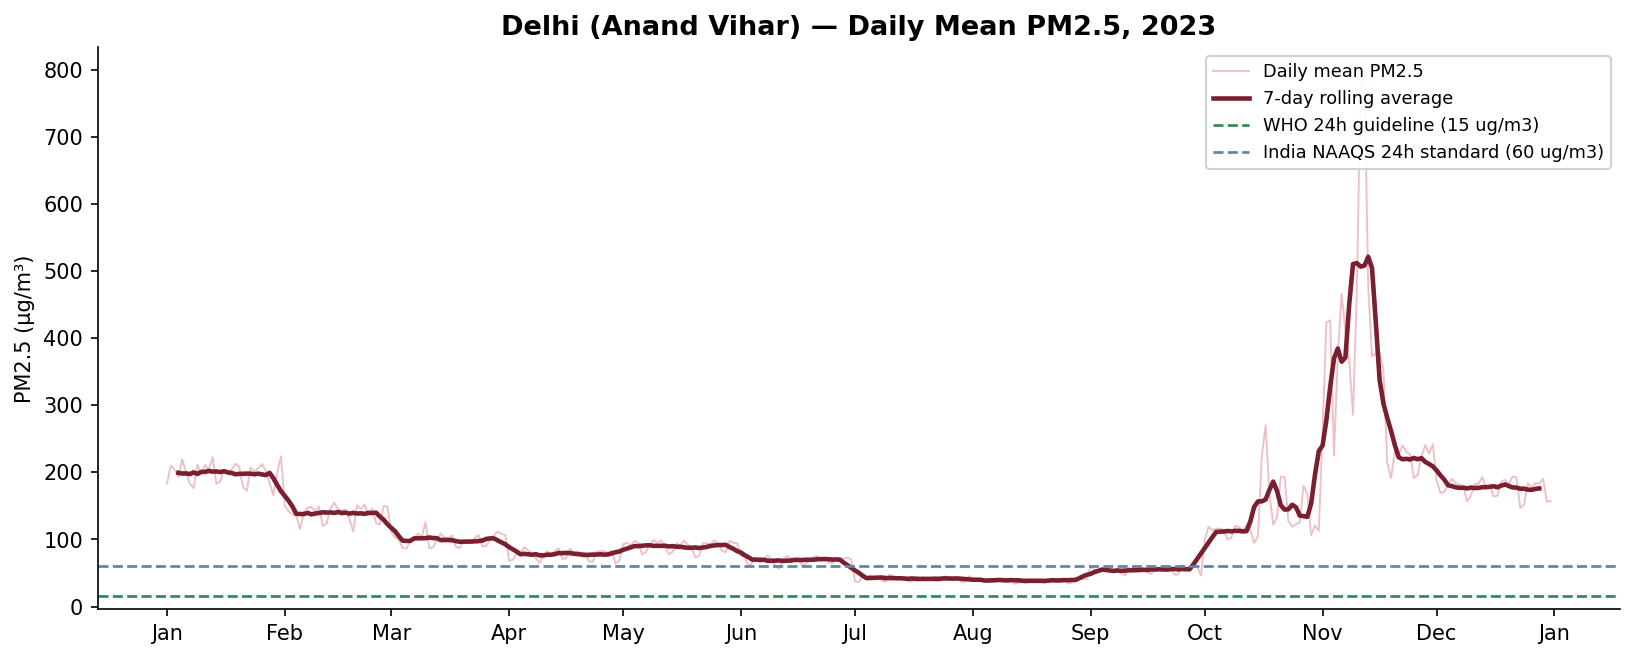

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(daily_avg.index, daily_avg["pm25"], color="#d1495b", alpha=0.35,
        linewidth=0.9, label="Daily mean PM2.5")
rolling7 = daily_avg["pm25"].rolling(7, center=True).mean()
ax.plot(daily_avg.index, rolling7, color="#7a1f30", linewidth=2.2,
        label="7-day rolling average")
ax.axhline(WHO_24H["pm25"], color="#2e8b57", linestyle="--", linewidth=1.3,
           label=f"WHO 24h guideline ({WHO_24H['pm25']} ug/m3)")
ax.axhline(NAAQS_24H["pm25"], color="#5b85aa", linestyle="--", linewidth=1.3,
           label=f"India NAAQS 24h standard ({NAAQS_24H['pm25']} ug/m3)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_title("Delhi (Anand Vihar) — Daily Mean PM2.5, 2023", fontsize=13, weight="bold")
ax.set_ylabel("PM2.5 (\u00b5g/m\u00b3)")
ax.legend(loc="upper right", fontsize=8.5, framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/chart1_yearly_trend_pm25.png", dpi=150, bbox_inches="tight")
plt.show()


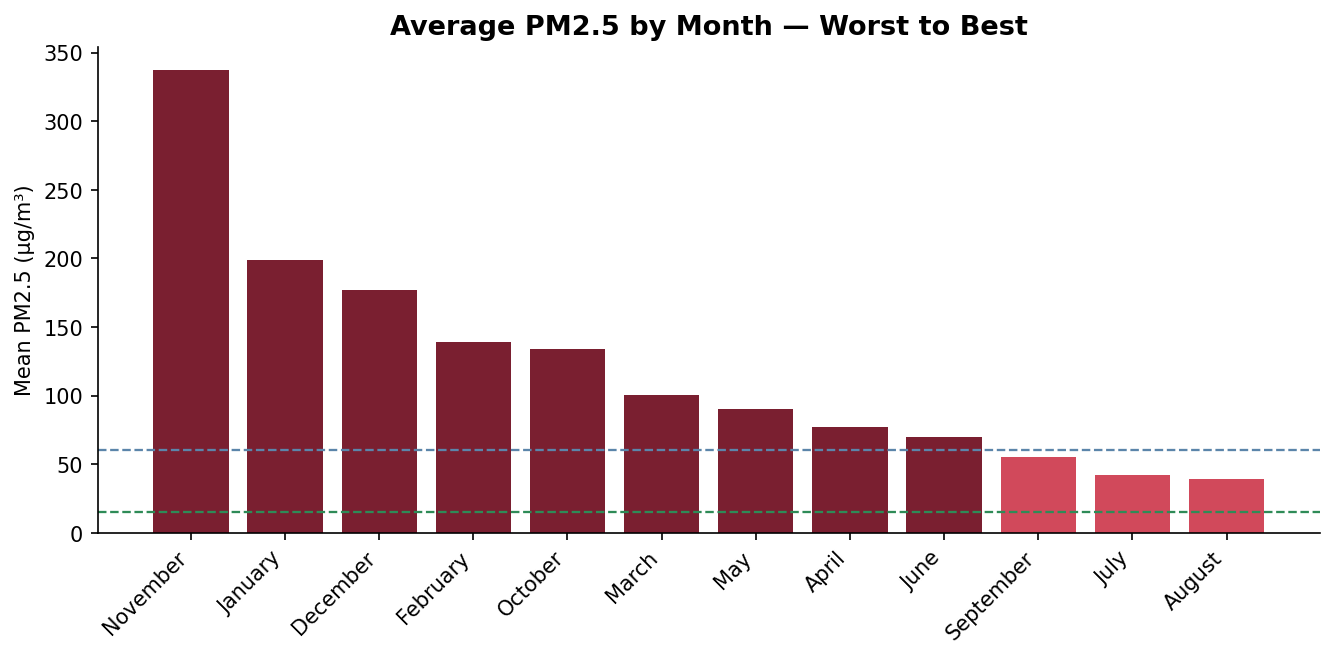

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = monthly_avg["pm25"].sort_values(ascending=False)
bar_colors = ["#7a1f30" if v >= NAAQS_24H["pm25"] else "#d1495b" if v >= WHO_24H["pm25"] else "#2e8b57"
              for v in order.values]
ax.bar(order.index, order.values, color=bar_colors)
ax.axhline(WHO_24H["pm25"], color="#2e8b57", linestyle="--", linewidth=1.1)
ax.axhline(NAAQS_24H["pm25"], color="#5b85aa", linestyle="--", linewidth=1.1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order.index, rotation=45, ha="right")
ax.set_title("Average PM2.5 by Month — Worst to Best", fontsize=13, weight="bold")
ax.set_ylabel("Mean PM2.5 (\u00b5g/m\u00b3)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/chart2_worst_months_bar.png", dpi=150, bbox_inches="tight")
plt.show()


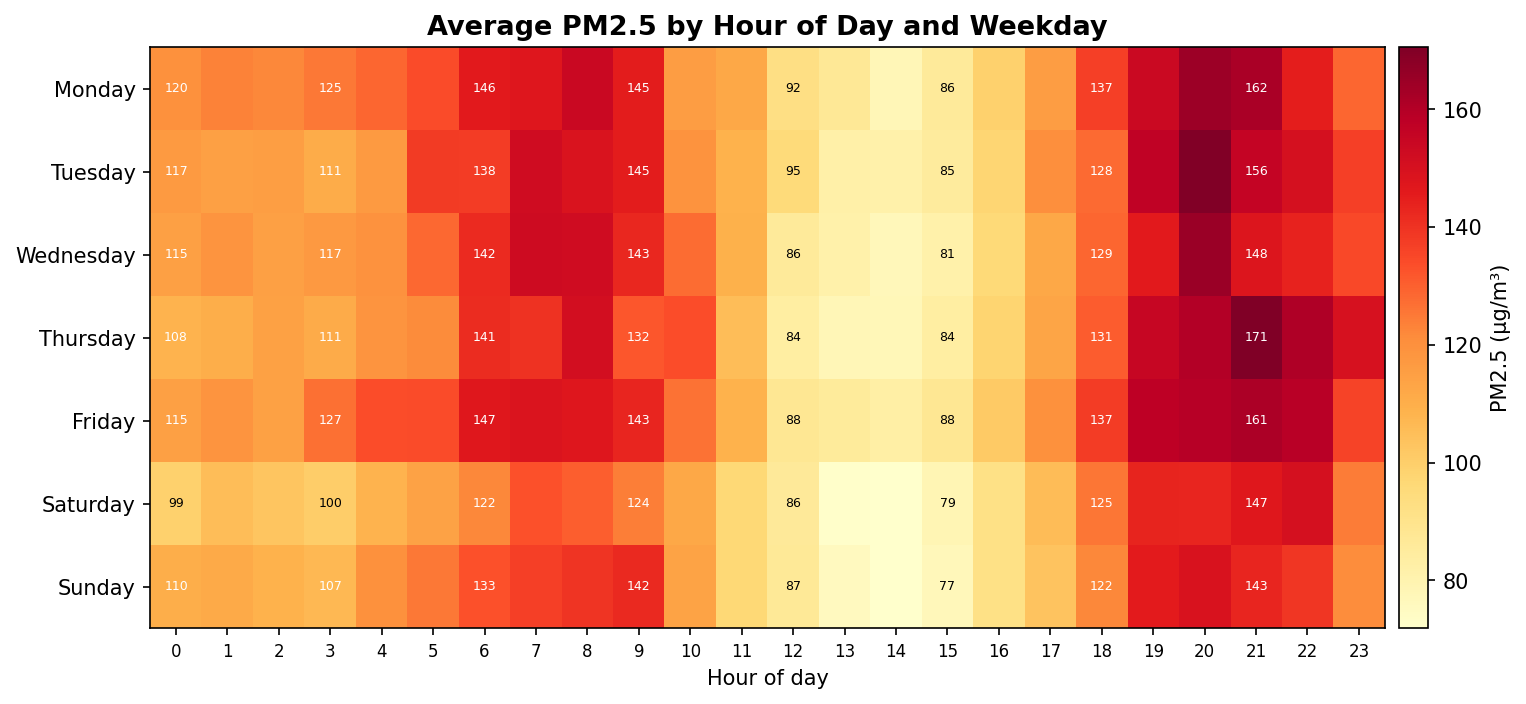

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.8))
data = hour_weekday_pm25.values
im = ax.imshow(data, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(24)); ax.set_xticklabels(range(24), fontsize=8)
ax.set_yticks(range(len(weekday_order))); ax.set_yticklabels(weekday_order)
ax.set_xlabel("Hour of day")
ax.set_title("Average PM2.5 by Hour of Day and Weekday", fontsize=13, weight="bold")
cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label("PM2.5 (\u00b5g/m\u00b3)")
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if j % 3 == 0:
            ax.text(j, i, f"{data[i,j]:.0f}", ha="center", va="center", fontsize=6,
                     color="black" if data[i,j] < np.nanmax(data)*0.6 else "white")
fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/chart3_hour_weekday_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


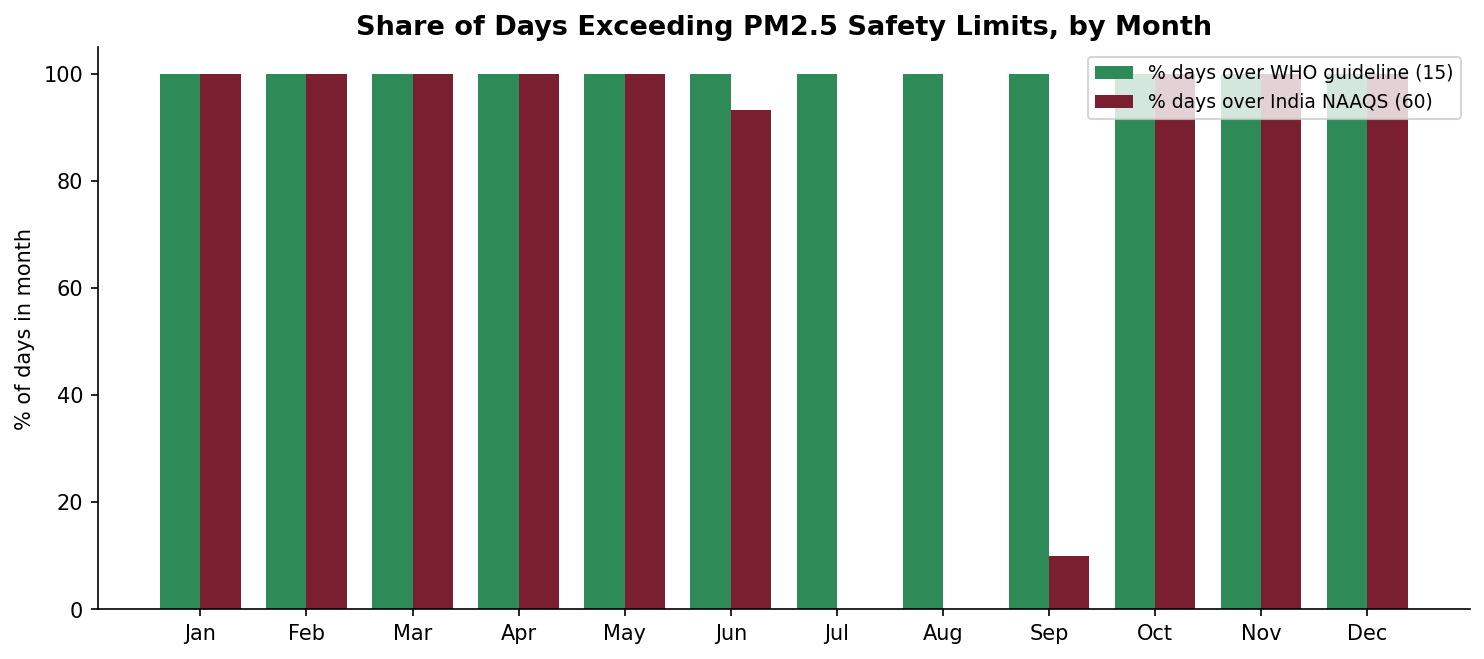

In [16]:
exceed_month = exceed.copy()
exceed_month["month_name"] = pd.to_datetime(exceed_month.index).month_name()
who_pct = (exceed_month.groupby("month_name")["pm25_over_who"].mean() * 100).reindex(month_order)
naaqs_pct = (exceed_month.groupby("month_name")["pm25_over_naaqs"].mean() * 100).reindex(month_order)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(month_order)); width = 0.38
ax.bar(x - width/2, who_pct.values, width, label="% days over WHO guideline (15)", color="#2e8b57")
ax.bar(x + width/2, naaqs_pct.values, width, label="% days over India NAAQS (60)", color="#7a1f30")
ax.set_xticks(x); ax.set_xticklabels([m[:3] for m in month_order])
ax.set_ylabel("% of days in month")
ax.set_title("Share of Days Exceeding PM2.5 Safety Limits, by Month", fontsize=13, weight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/chart4_who_exceedance.png", dpi=150, bbox_inches="tight")
plt.show()


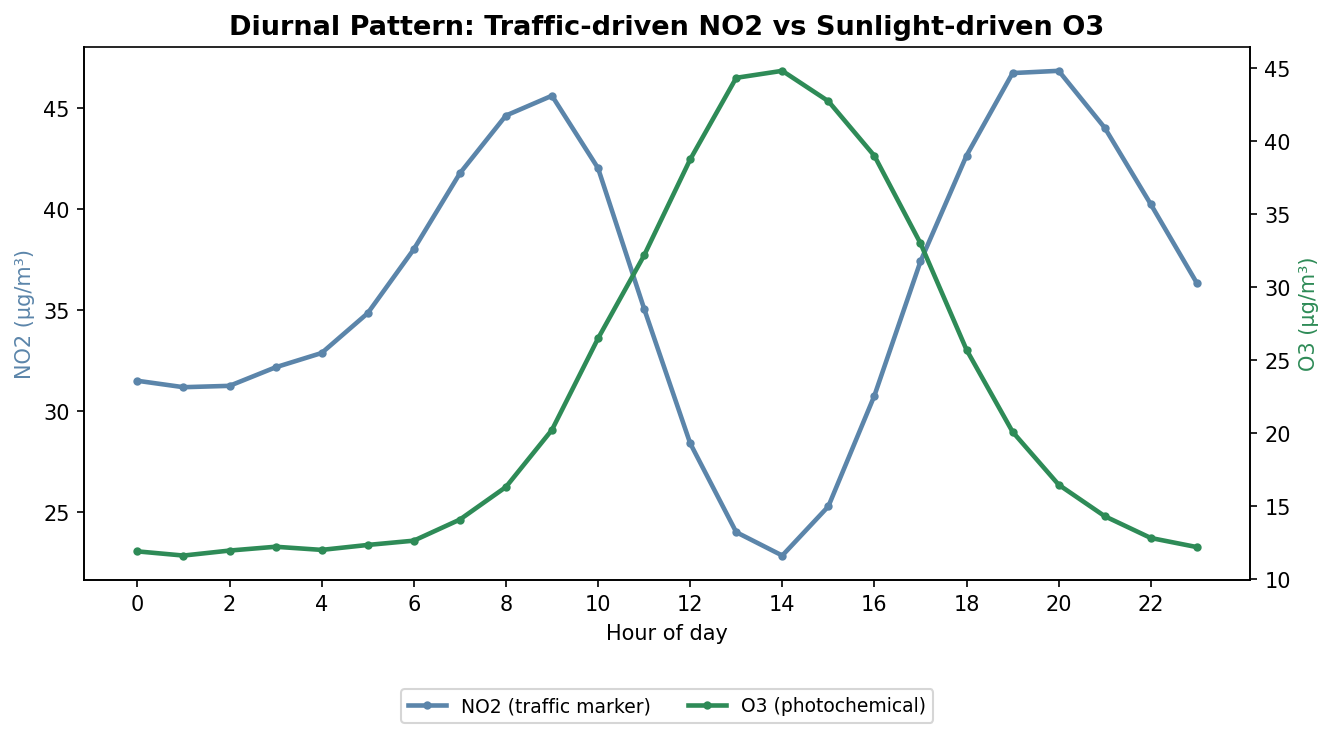

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hourly_avg.index, hourly_avg["no2"], color="#5b85aa", linewidth=2.2,
        marker="o", markersize=3, label="NO2 (traffic marker)")
ax2 = ax.twinx()
ax2.plot(hourly_avg.index, hourly_avg["o3"], color="#2e8b57", linewidth=2.2,
         marker="o", markersize=3, label="O3 (photochemical)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("NO2 (\u00b5g/m\u00b3)", color="#5b85aa")
ax2.set_ylabel("O3 (\u00b5g/m\u00b3)", color="#2e8b57")
ax.set_xticks(range(0, 24, 2))
ax.set_title("Diurnal Pattern: Traffic-driven NO2 vs Sunlight-driven O3", fontsize=13, weight="bold")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=9)
ax.spines["top"].set_visible(False)
fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/chart5_diurnal_no2_o3.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 6 — Findings

**Worst month: November (337 µg/m³ mean PM2.5)** — roughly 8x the cleanest
month. December and January follow (177 and 199 µg/m³). **Best month: August
(39 µg/m³)** — far better than winter, but still over 2.5x the WHO guideline.

**Worst hour: 8–9 PM**, with a secondary peak at 7–9 AM; the cleanest air is
consistently around **2 PM**. **Weekdays (124 µg/m³) run higher than weekends
(114 µg/m³)** — a modest but real traffic signature, much smaller than the
seasonal swing.

**Safety limits:** PM2.5 exceeded the WHO 24-hour guideline (15 µg/m³) on
**100% of days all year**, and exceeded India's own, much looser national
standard (60 µg/m³) on **75% of days** — dropping to 0% in July–August and
climbing back to 100% by October.

**Most plausible reason:** the winter spike lines up with three things that
all worsen together from late October through January — post-monsoon **crop
residue (stubble) burning**, **falling temperatures trapping a shallow
boundary layer** close to the ground, and **calm winds** (our data shows
winter winds roughly half of pre-monsoon speeds). Diwali (mid-November) sits
right inside this window, which is why November edges out December/January
as the single worst month. The diurnal chart supports the traffic story:
NO2 peaks sharply at rush hours, while O3 (which needs sunlight to form)
peaks at the opposite time of day, around 2 PM.

**Caveat:** the two multi-day sensor outages (Mar 10–11, Aug 5–7) were filled
by interpolation — treat those specific windows as lower-confidence
estimates, not real readings. This is also a single, traffic-heavy station;
a city-wide average would likely run somewhat lower.


## Next steps (extensions)

- Wrap the cleaning steps above into reusable functions / a small CLI that
  takes any city's raw CSV and produces this same report.
- Pull a second station (or city) and overlay it on the same axes.
- Use this cleaned dataset as the input to a next-day PM2.5 forecasting model.
